<a href="https://colab.research.google.com/github/franciscoweitzman-cyber/aps_francisco_weitzman/blob/main/TS2/TS2_WEITZMAN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#### Análisis y Procesamiento de Señales

# Trabajo Práctico Nº2
#### por: Francisco Weitzman

##Introducción
Nos introducimos en la fabricación de un ADC digital con una señal "real" simulada para entender cómo tratar con una señal digitalizada y entender los efectos de la cuantización.

Cuantizar significa pasar valores —continuos o discretos— a unos valores muy específicos y de dominio discreto. Se utiliza un comparador o una función de redondeo para pasar de un valor inicial (por ejemplo $π$) a un valor cuantizado (por ejemplo a 3,1). Los valores cuantizados están definidos por un techo, un piso y un paso o step, que es la mínima unidad de cambio.

Esto nos remite a la idea de la Física Cuántica, planteada por el gran físico Max Planck a fines del siglo XVIII para resolver el problema de la catástrofe ultravioleta, problema que resuelve con elegancia al cuantizar la energía ($E = \frac{hc}{λ}$), aunque no sin que a esta la acompañe una gran disociación con nuestra previa comprensión de la realidad. Esto generó un gran disgusto a lo largo y ancho de todo el espectro académico, empezando por él mismo. La realidad es que, sin ese avance, absolutamente nada de lo que hoy conocemos existiría; ni los transistores, ni los procesadores, ni seguramente la necesidad de cuantizar señales ya que no tendríamos computadoras digitales para procesarlas, y seguramente tendría sentido usar voltímetros analógicos para el caso.

El dispositivo que usamos para _Cuantizar_ una señal es un ADC (Conversor Analógico Digital por sus siglas en inglés).

El paso de cuantización, nombrado qq en nuestro código, es:

$qq = \frac{V_{F}}{2^{B-1}}$,    con $V_{F}$ siendo el valor del techo con respecto a la mitad del intervalo total y B siendo la cantidad de bits que pueden representar los voltajes de la señal. Está claro que al aumentar la cantidad de bits, aumento la resolución de la representación de mi señal, ya que entre dos bits consecutivos, hay un salto qq menor cuanto mayor es el número de bits. Se puede ver claramente si analizamos el error por cuantización, dado por la siguiente expresión:

$Pot_{q} = \frac{qq^2}{12}$. Vemos que la potencia de cada step disminuye cuadráticamente conforme incrementemos la cantidad de bits para conservar los valores de nuestra lectura.

Para finalizar, análogo (especial uso de la palabra) a lo que nos enseñó Planck en los niveles de energía de un fotón, nuestro valor de voltaje no puede caer entre dos bits consecutivos, por eso se usa la función redondeo, y la cota máxima del error debe ser $|V_{real}-V_{q}| ≤ \frac{1}{2}*qq$

## Desarrollo
(Disclaimer 1) [Anteriormente, subía los códigos de los gráficos. A medida que avanza la materia, me doy cuenta de que se vuelven cada vez más largos y específicos las TS's, así que subo el código para mostrar lo que hice, y el codigo completo queda subido en el repositorio cualquier cosa que quieran revisar]


(Disclaimer 2) [Aprendí a graficar en python, pero cada vez que hago un nuevo gráfico, lo armo con IA, a menos que pueda modificar uno similar. Considero que usar tiempo y cabeza en eso no es tan relevante como sí analizarlo bajo la lupa, además que no soy muy estético con la creación de gráficos y se embarra un poco la información. El resto del código es 100% mío, a excepción de una corrección o busqueda de error, que inicialmente lo charlo con compañeros antes de acudir a una IA. Suelo usar Gemini]

Ahora que están hechas todas las aclaraciones, procedo con el desarrollo. Procedemos como siempre creando nuestra función "analógica", su ruido "analógico" con los parámetros requeridos.

In [ ]:
# -*- coding: utf-8 -*-
"""
Created on Tue Sep  8 16:45:38 2026
@author: Fran
"""
import numpy as np
import matplotlib.pyplot as plt
#np.sqrt(2) es la amplitud que necesito para una potencia de 1W
#V**2/2 = potencia
def mi_funcion_sen(vmax, dc, ff, ph, nn, fs):
    xx=dc+vmax*np.sin(2*np.pi*ff*nn/fs+2*np.pi*ph)
    tt=nn/fs
    return(tt,xx)

In [ ]:
#%% Parametros iniciales y sinudoiudal

fs = 1000 # Hz
N = 1000 # muestras
vmax=np.sqrt(2) #pot = 1W
dc=0 # Valor medio (alrededor del que oscila)
df=fs/N # frecuencia de la señal, va a ser nuestra f0
k=1
kdf=k*df
ph=0
nn=np.arange(0,N)
mu=0 #valor medio
tt, xx= mi_funcion_sen(vmax, dc, kdf, ph, nn, fs)

Ahora vamos a definir los valores de nuestro ADC. Eso incluye
*   la cantidad de bits que vamos a usar para guardar los valores de voltaje,
*   el Vfs que representa el máximo valor módulo de voltaje (es decir, nuestras mediciones van a tomar un valor dentro del intervalo

    [-Vfs;Vfs]. Cualquier valor mayor o menor va a saturar)
*   el qq que es el mínimo valor de cambio de voltaje, conocido como paso o step
*   y por último pero no menos importante, la potencia del ruido de cuantización.

In [ ]:
#%% ADC (Analog to Digital Conversor)

B=4 # Bits
Vfs=2 #Volts
qq=(2*Vfs/(2**B))#paso de cuantización
pot_rui_cuant = (qq**2)/12 # Potencia de entrada de cuantización
# 2pi/N Resoloucion muestral.

In [ ]:
#%% Terminamos de definir unos valores

k_n = 1
pot_ruido= k_n*pot_rui_cuant #q**2/12 * k_n, k_n un factor de proporcionalidad
yy=np.random.normal(mu,np.sqrt(pot_ruido),N)
funcion_con_ruido=xx+yy

Y ahora sí, vamos a proceder con la Cuantización.

## Cuantizacion
El xx_q consta en redondear la división señal/qq y luego devolverla a su orden de magnitud original al multiplicarlo nuevamente por qq. Esto nos da valores que se pueden representar como múltiplos de qq, que es exactamente lo que queremos hacer.


In [ ]:
#%% Quantizacion

xx_q = np.round(funcion_con_ruido/qq)*qq # Cuantizamos

# Ruido de cuantización
nq = xx_q - funcion_con_ruido # error de cuantizacion (ruido)

# FFT de la señal cuantizada:
fft_q = np.fft.fft(xx_q)/N
modulo_q = np.abs(fft_q[:N//2])
modulo_q[1:] = 2 * modulo_q[1:] # Normalizamos
modulo_q_db = 20*np.log10(modulo_q/vmax)
eje_frecuencias = np.arange(N//2) * fs/N

# FFT de la Señal Con ruido
fft = np.fft.fft(funcion_con_ruido)/N
modulo = np.abs(fft[:N//2])
modulo[1:] = 2 * modulo[1:]
modulo_db = 20*np.log10(modulo/vmax)

media_q = (np.arange(0,N//2)*0)+np.mean(modulo_q_db)
media = (np.arange(0,N//2)*0)+np.mean(modulo_db)

Graficamos la señal pura, la señal con ruido "analógico" y la señal digitalizada en un mismo plot. Vemos claramente los pasos de cuantización (en gris). Proximamente, analizaremos los impactos de esta cuantización en nuestra señal.

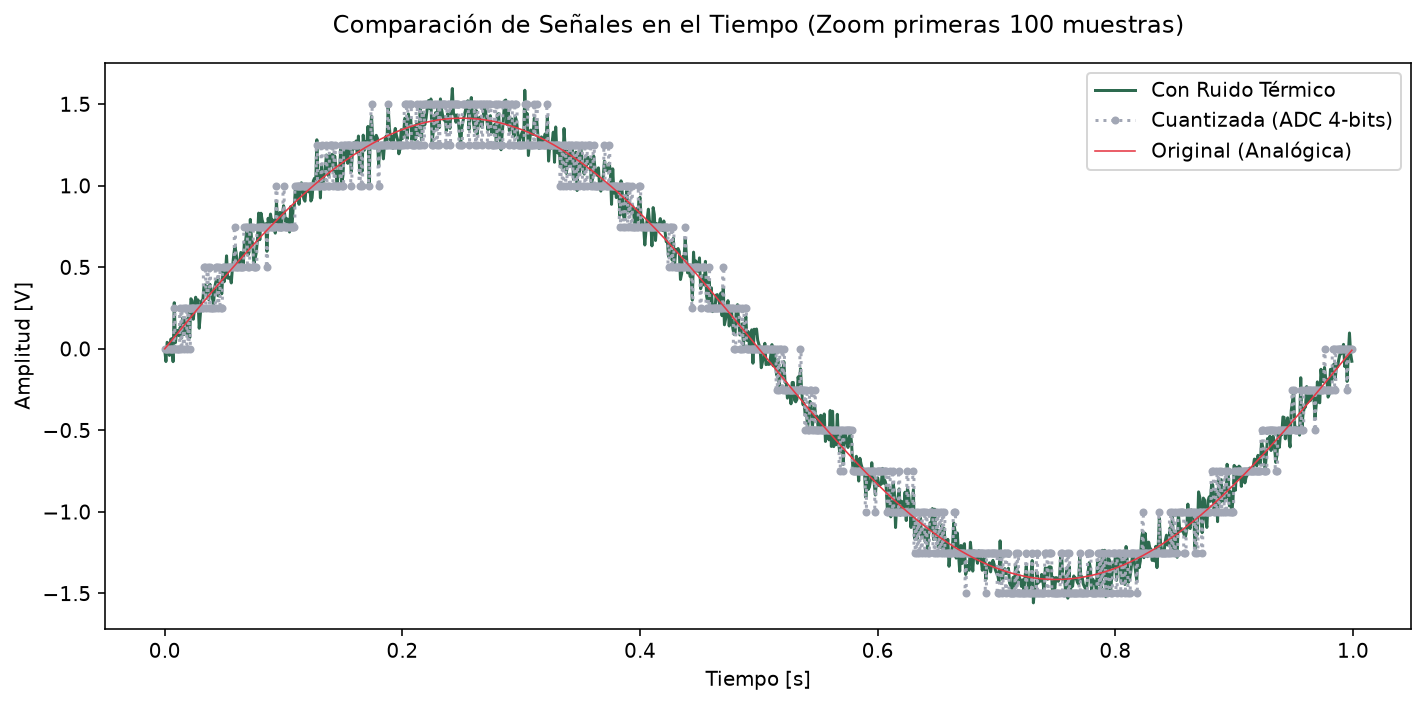

Luego de transformar en una DFT las dos señales, la "analógica" y la digitalizada, graficamos sus transformadas. Notamos que es más ruidosa la señal cuantizada. Creo que es de esperarse eso por un par de razones. Para empezar, la señal cuantizada son escalones o deltas, similar a la onda cuadrada de la TS1. Esto aporta amplitud en armónicos impares de las fundamentales de esos escalones que "luchan" por ajustarse a la derivada infinita que significa saltar de un escalón a otro. Sería interesante ver si se reduce el nivel de ruido por cuantización si se toman menos muestras, o si por lo contrario aumenta por efecto de la Sinc. Siguiendo con las razones, estamos redondeando el valor de la señal, y eso puede dar "picos" de ruido más altos que seguramente aporten a que el piso o media de ruido de cuantización aumente sutilmente.

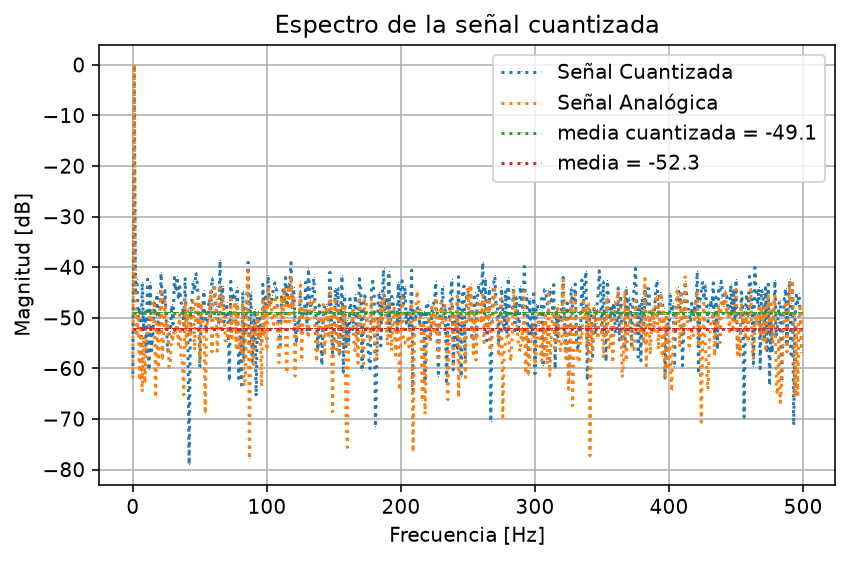

In [ ]:
#%% Autocorrelacion ruido cuantización
autocorr_nq = np.correlate(nq, nq, mode='full')
retardos = np.arange(-N + 1, N) # Eje de retardos (lags)

Analizamos la autocorrelación del ruido de cuantización. Lo que podemos ver es que al calcular la autocorrelación del "nq", tenemos un pico de más de 5 en el lag = 0 y valores entre -0,5 y 0,5.

La autocorrelación se define como:

$R_{x}[n]=\sum_{i}{x[i]}{x[i+n]}$

claramente, un prima hermana de la convolución. Vemos que estamos comparando cuánto coinciden ambas funciones y se suman término a término, dando lugar a un escalar que indica de alguna manera "cuanto coinciden". Una especie de Producto Interno de una funcion consigo misma desplazada. Si fueran dos senos de la misma frecuencia, darían su correlación máxima para cuando el desplazamiento sea $2nπf$ y 0 para cuando el desplazamiento sea $nπf+\frac{π}{2}$. En fin, la cuestión es que solo "suman" a una amplitud notoriamente grande cuando el retardo es 0 o equivalente, en otras palabras, es la misma función. Más precisamente, vale $N*\frac{qq^2}{12} = 1000 * 0.00521 ≈ 5,2$. Todo cierra hermosamente. Otra cosa que se puede decir, es que, por suerte, se puede considerar como ruido blanco por su comportamiento incorrelado, que es una de las razones por las que el gráfico de la DFT nos dio con un pico grande en la frecuencia de nuestro seno sin ningún tipo de ruido.

La razón por la que por fuera del retardo el ruido no sea 0 tiene que ver con la cantidad de muestras. A mayor sea nuestra cantidad de muestras, más va a tender a estar equilibrado las sumas de los ruidos, haciendo que la autocorrelación tienda a 0. Por otro lado, el hecho que oscile entre -0,5 y 0,5 tiene que ver con un limite que se calcula así:

$σ_{R} \approx \frac{Amplitud(n=0)}{\sqrt{N}} \approx 0,17$

además,

$lim = ± 3*σ = ± 0,51$, ¡los mismos límites que vemos en el gráfico!
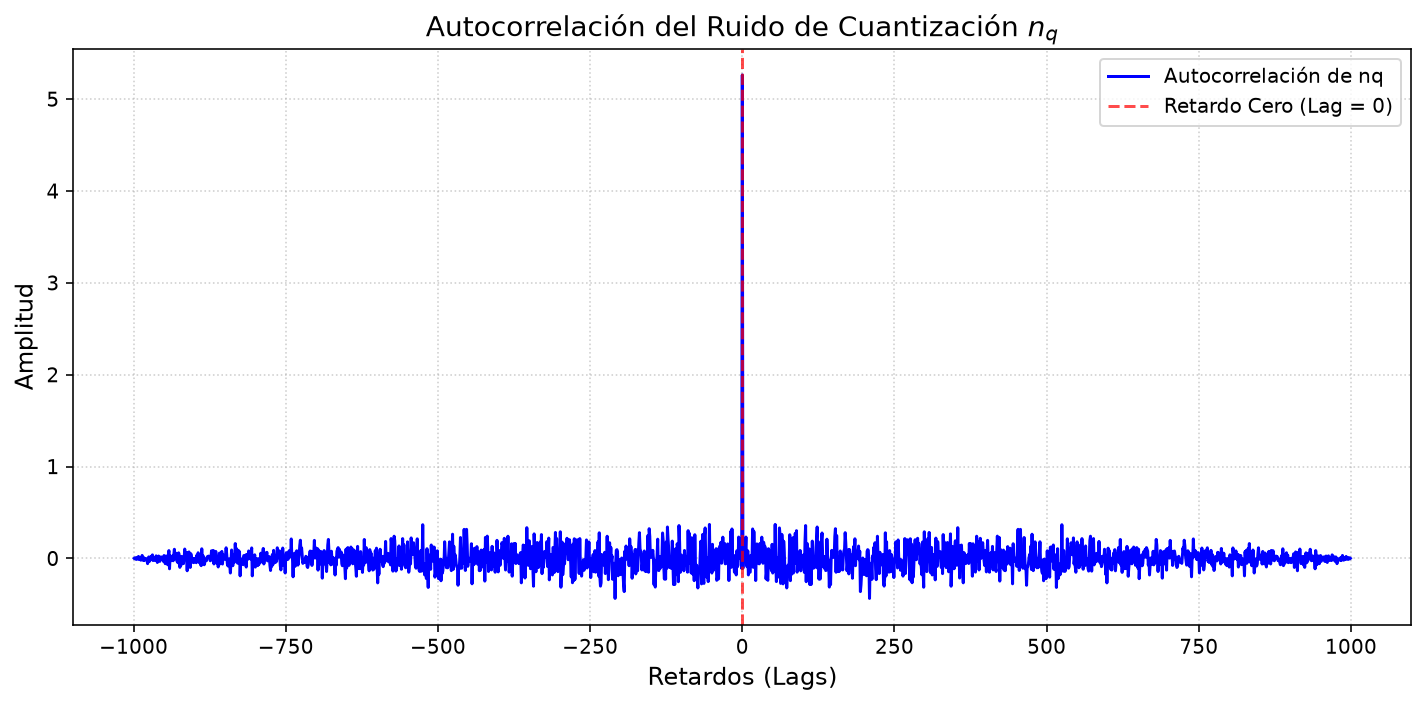

## Item B
Vamos a armar el mismo experimento y analizar los resultados con los siguientes valores:

*   $K_{n} = 10$
*   $B = 8$






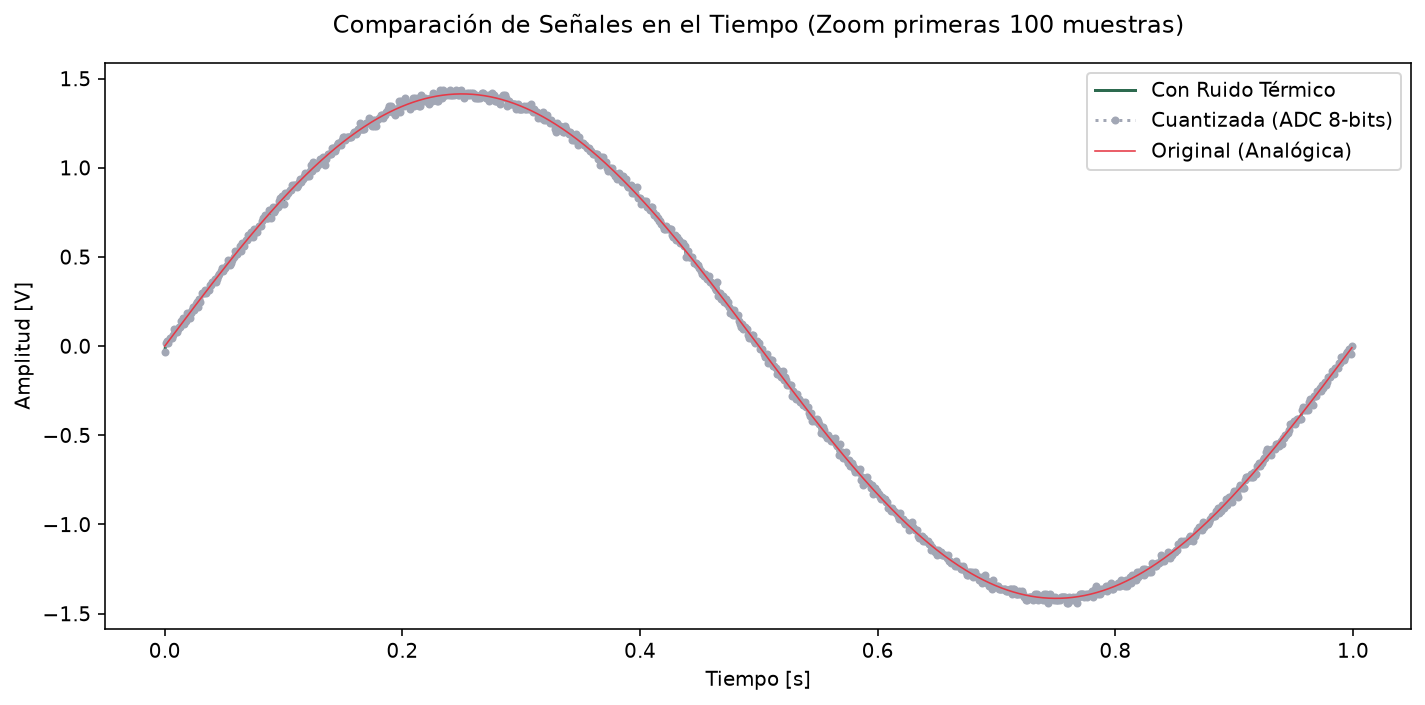

Acá ya empezamos a notar que el ruido, en general, es significativamente menor. Veamos el ruido en la DFT:

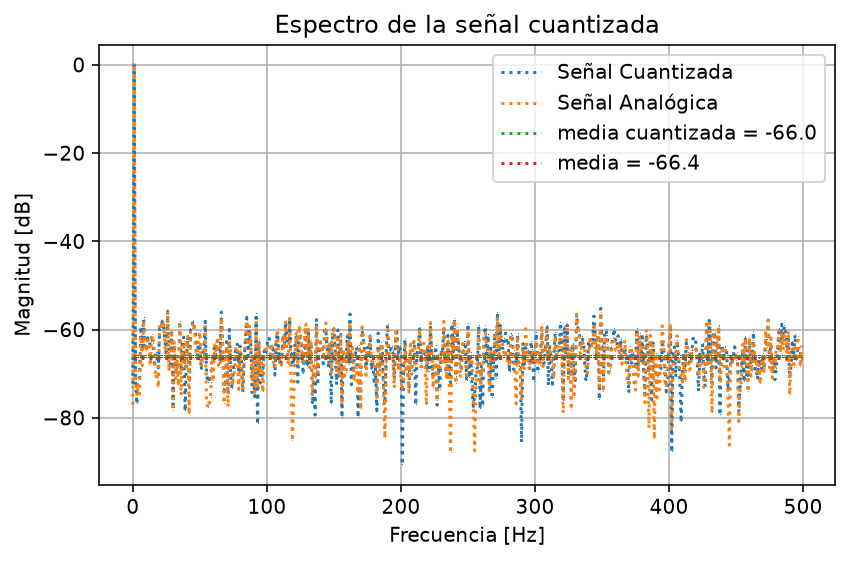

Desde el vamos, podemos observar que hay un orden de al menos 10 dB menos en esta configuración que en la anterior. Otra cosa que podemos decir es que hay 0,4dB de diferencia entre las dos medias. Esto lo podemos explicar porque habíamos definido que:

$P_{analógico} = K_{n}*P_{q}$ ,

entonces nuestro ruido analógico es 10 veces más que nuestro ruido de cuantización.

Por otro lado, al aumentar nuestra cantidad de Bins, redujimos cuadráticamente la potencia de cuantización, como mencionamos antes, entonces nuestros errores son bastante más chicos que antes.

En cuanto al gráfico de la DFT, vemos que las medias siguen cumpliendo con que la del ruido de cuantización es mayor que la media del analógico. Nuevamente, esto es porque ambos ruidos son incorrelados. Eso se ve claramente en el siguiente gráfico:

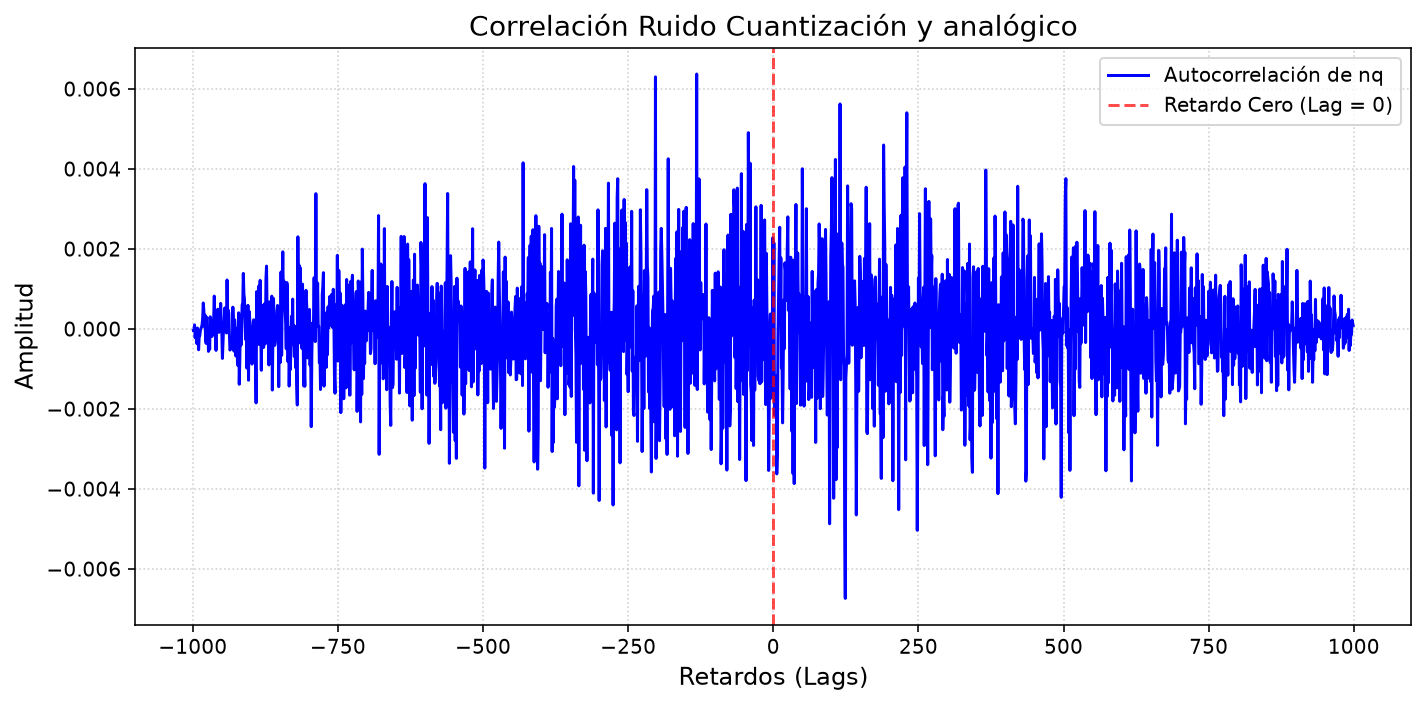

Este gráfico lo expongo unicamente para mostrar cómo disminuye el ruido fuera del retardo = 0, eso es por la ecuación

$σ_{R} \approx \frac{Amplitud(n=0)}{\sqrt{N}}$

y la amplitud en el 0 es 250 veces menor que antes.

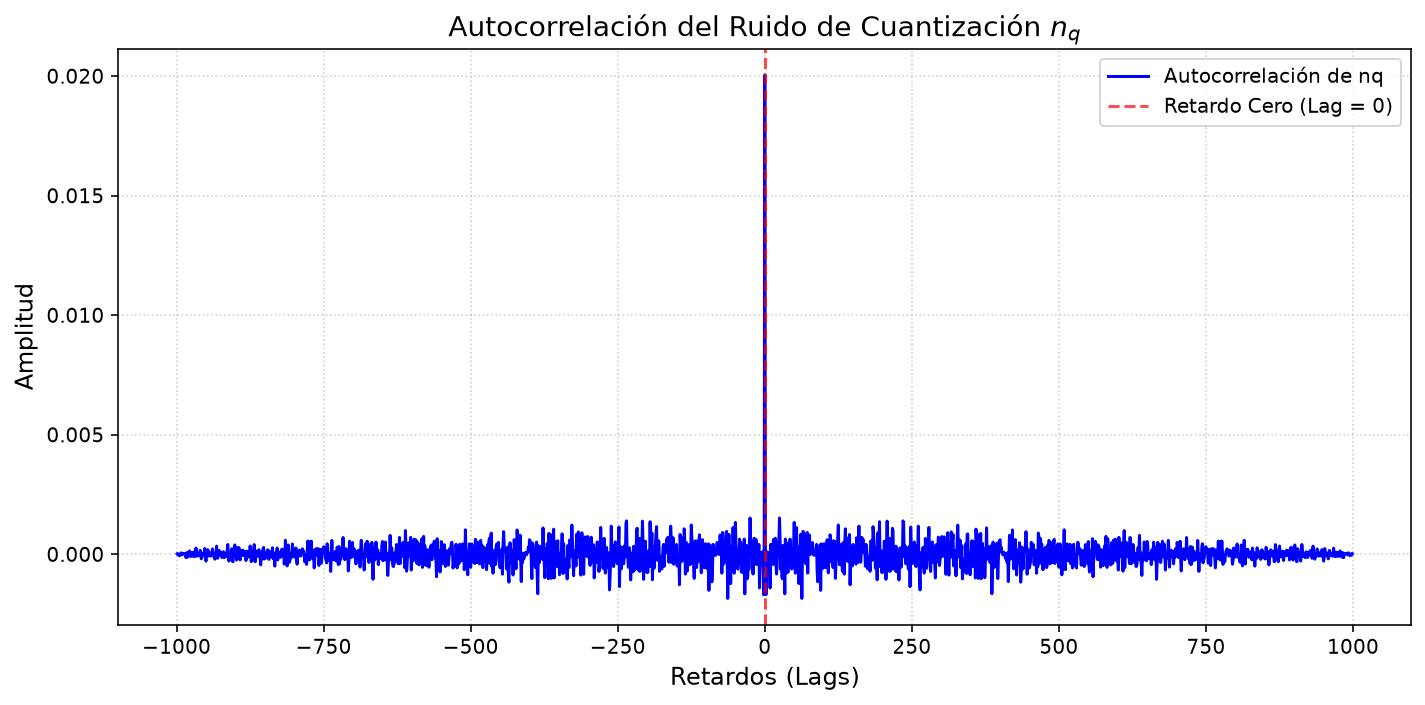

Vemos que se sigue manteniendo la relación uniforme de este histograma, lo que nos reafirma la aleatoriedad uniforme de la cuantización: si la resta de la señal analógica y la digitalizada cae entre [-qq/2;qq/2), el valor cuantizado es el mismo, y esa diferencia entre ambas señales puede caer en cualquier lugar de ese intervalo sin "preferencias" (o cesgos?)

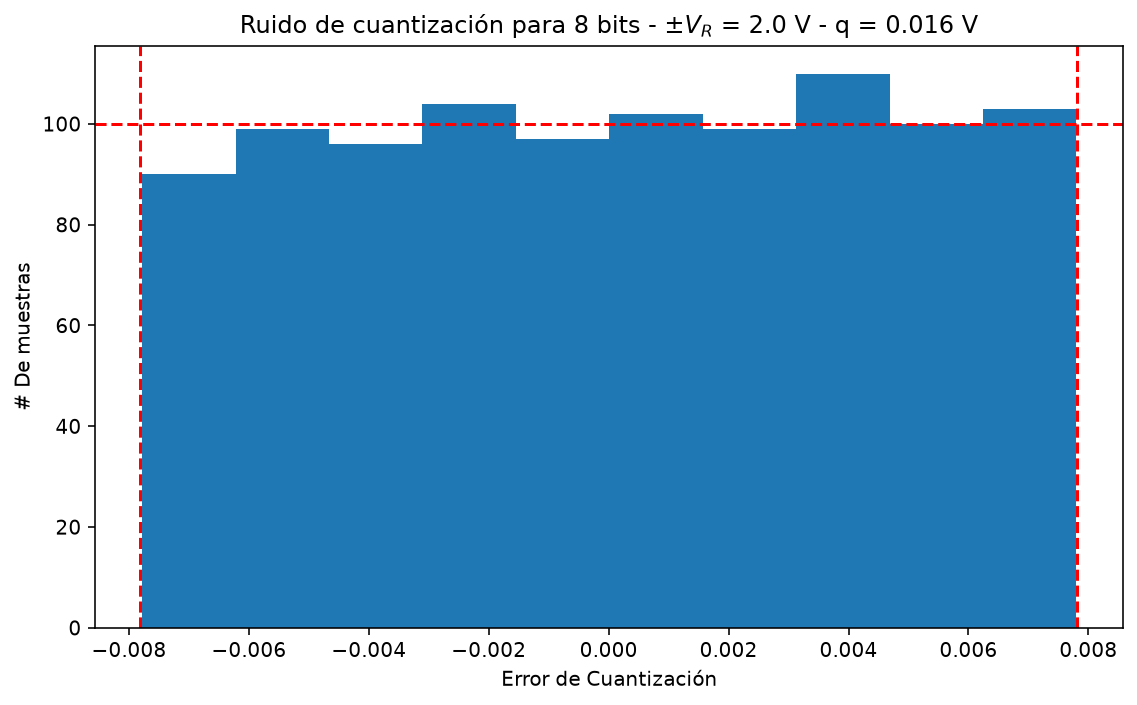

Por último, acá reafirmamos lo que sabíamos de antes y por obviedad matemática, si el ruido "nq" se saliera del intervalo [-qq/2;qq/2), pasaría al siguiente bit.

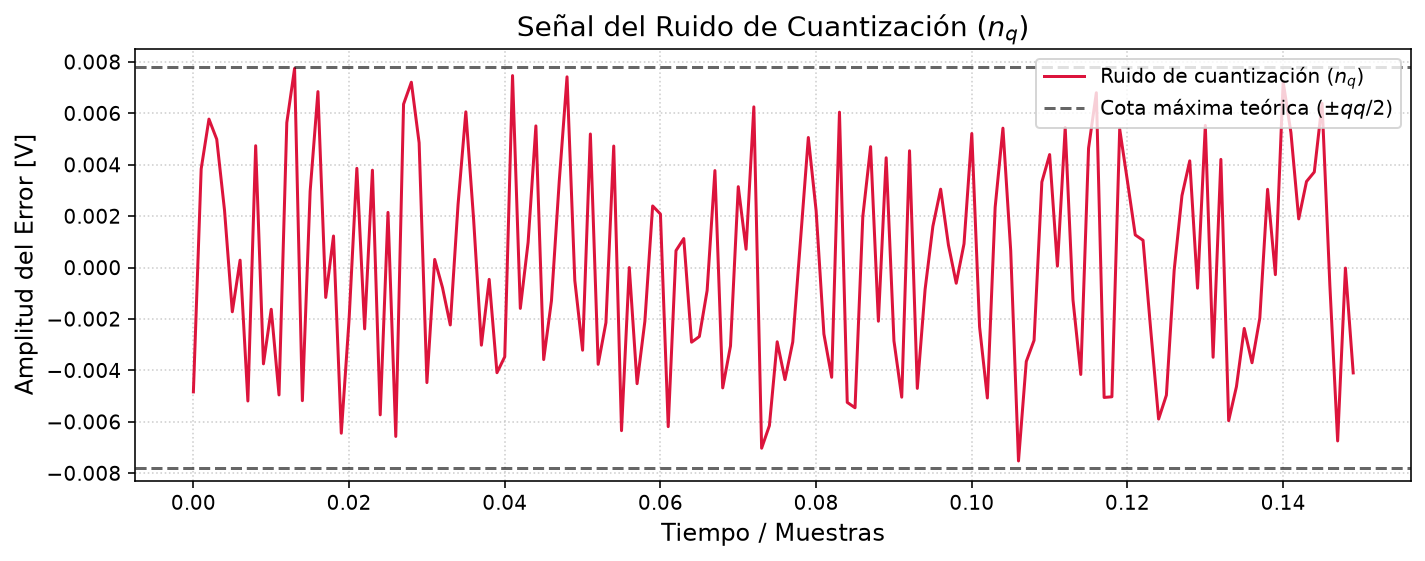

#Conclusiones
En este trabajo aprendí sobre la correlacion de señales, de cómo cuantizar una señal y cuáles son las implicancias de esta acción. Analicé también cómo cambian sus efectos según los valores de Bits que elijo y la relación de potencias entre ambos ruidos. Se nota claramente, por ejemplo, que prevalece la potencia de un ruido o el otro según esa relación o ratio que tengan.